# 12 - EDA: Geographic Sentiment Analysis (Production Dataset)
## ShopEase Europe | Sentiment Analysis Project - Phase 2 
**Objective:** Analyse sentiment patterns across countries, focusing 
on high volume markets given the dataset's heavy concentration in 
the United States and United Kingdom.

## Import Libaries

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


## Load the Dataset

In [2]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
PROCESSED_DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed', 'production_preprocessed_reviews.csv')
FIGURES_PATH = os.path.join(PROJECT_ROOT, 'reports', 'figures')

df = pd.read_csv(PROCESSED_DATA_PATH)

print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Total countries: {df['country'].nunique()}")

Dataset loaded: 21,055 rows x 11 columns
Total countries: 149


## Sentiment by Top Markets
Focusing on the top 10 countries by review volume, since the 
remaining 138 countries contribute too few reviews for reliable analysis.

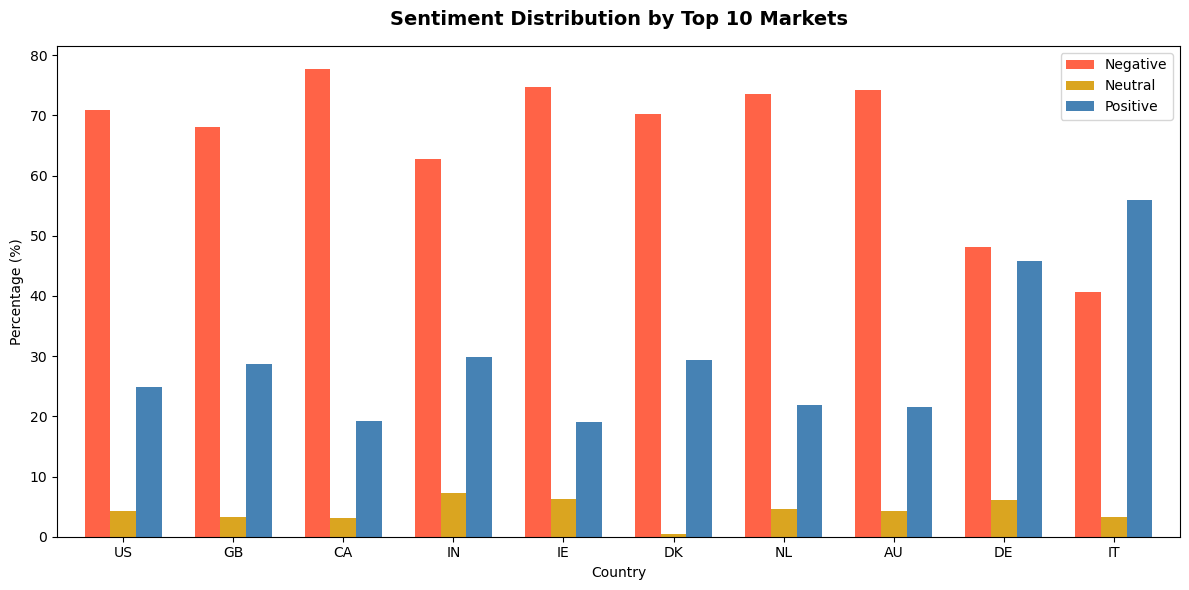

In [3]:
top_countries = df['country'].value_counts().head(10).index
df_top = df[df['country'].isin(top_countries)]

country_sentiment = df_top.groupby(['country', 'sentiment']).size().unstack(fill_value=0)
country_sentiment_pct = country_sentiment.div(country_sentiment.sum(axis=1), axis=0) * 100
country_sentiment_pct = country_sentiment_pct.reindex(top_countries)

fig, ax = plt.subplots(figsize=(12, 6))
country_sentiment_pct.plot(kind='bar', ax=ax, color=['tomato', 'goldenrod', 'steelblue'], width=0.7)
ax.set_title('Sentiment Distribution by Top 10 Markets', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Country')
ax.set_ylabel('Percentage (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(['Negative', 'Neutral', 'Positive'], loc='upper right')
ax.grid(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'production_sentiment_by_country.png'), dpi=150, bbox_inches='tight')
plt.show()

## Top Markets Sentiment Finding

Sentiment varies meaningfully across top markets, ranging from 78% 
negative in Canada to just 41% negative in Italy, the only market 
where positive sentiment exceeds negative. Germany also stands out 
with a near balanced profile at 48% negative and 46% positive, 
markedly better than the US and GB, which sit closer to the dataset 
average at 71% and 68% negative respectively.

**Insight:** Italy and Germany's notably more favourable sentiment 
profiles, despite lower review volumes, suggest these markets may be 
experiencing meaningfully different service quality, delivery 
performance, or customer support standards compared to the dominant 
US and GB markets. This warrants further investigation into whether 
operational practices differ by region, since replicating whatever is 
working in Italy and Germany could offer a tangible path to improving 
sentiment in larger, more troubled markets like Canada and the US.

## Review Volume by Country

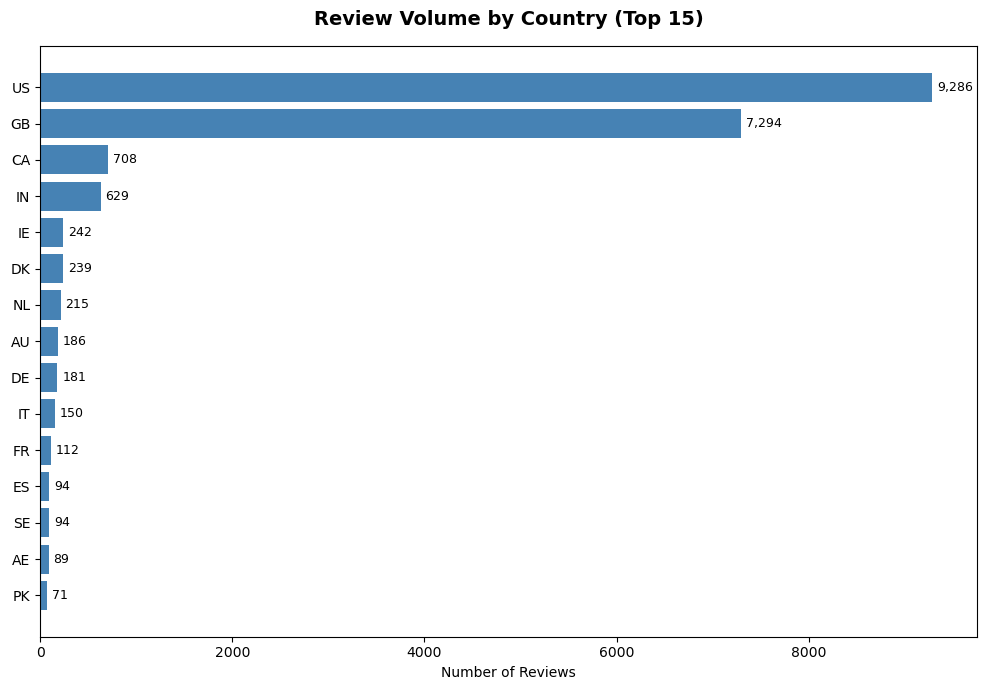

In [4]:
top_15_countries = df['country'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_15_countries.index[::-1], top_15_countries.values[::-1], color='steelblue')
ax.set_title('Review Volume by Country (Top 15)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Reviews')
ax.grid(False)

for i, count in enumerate(top_15_countries.values[::-1]):
    ax.text(count + 50, i, f'{count:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'production_review_volume_by_country.png'), dpi=150, bbox_inches='tight')
plt.show()

## Review Volume Finding

Review volume is extremely concentrated, the US alone accounts for 
9,286 reviews and GB for 7,294, together representing 79% of the 
entire dataset. Every other country falls below 1,000 reviews, with 
Canada in third place at just 708.

**Insight:** This context is important when interpreting the earlier 
sentiment finding, Italy's favourable 41% negative rate is based on 
only 150 reviews, and Germany's 48% on just 181. While these patterns 
are worth investigating further, they should be treated as directional 
signals rather than statistically robust conclusions given the limited 
sample sizes. The US and GB figures, by contrast, carry far greater 
statistical reliability given their substantial review volumes.

## Sentiment Trend by Top Market
Comparing the sentiment decline trend between the US and GB, the two 
markets with sufficient volume across all years for reliable comparison.

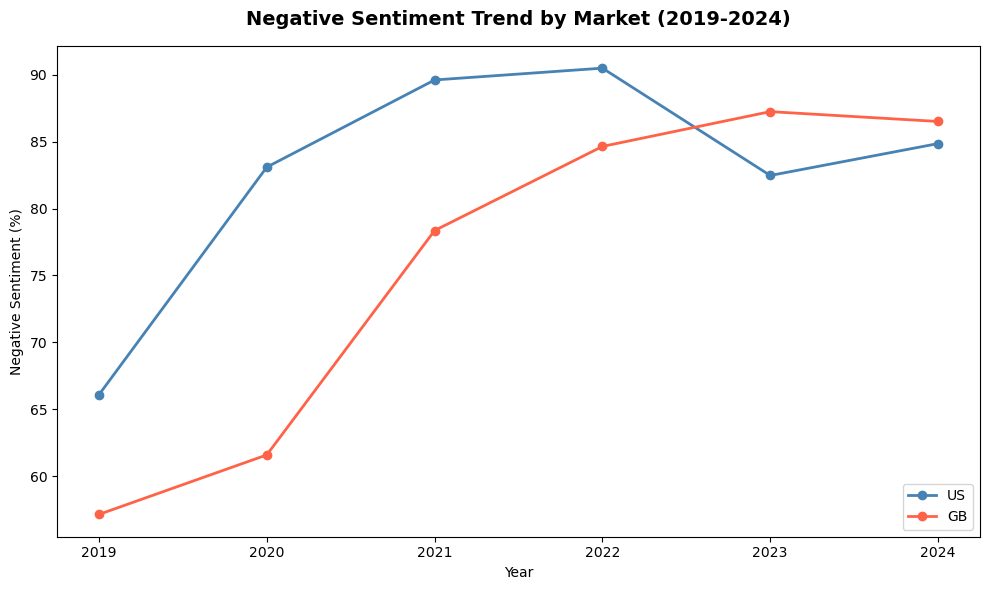

In [5]:
df_recent = df[df['year'] >= 2019]
df_us_gb = df_recent[df_recent['country'].isin(['US', 'GB'])]

trend = df_us_gb.groupby(['year', 'country', 'sentiment']).size().unstack(fill_value=0)
trend_pct = trend.div(trend.sum(axis=1), axis=0) * 100
negative_trend = trend_pct['negative'].unstack(level='country')

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(negative_trend.index, negative_trend['US'], color='steelblue', linewidth=2, marker='o', label='US')
ax.plot(negative_trend.index, negative_trend['GB'], color='tomato', linewidth=2, marker='o', label='GB')

ax.set_title('Negative Sentiment Trend by Market (2019-2024)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('Negative Sentiment (%)')
ax.legend(loc='lower right')
ax.grid(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'production_sentiment_trend_by_market.png'), dpi=150, bbox_inches='tight')
plt.show()

## Sentiment Trend by Market Finding

Both the US and GB show a clear multi year rise in negative sentiment, 
but with different timing. US negative sentiment climbed sharply from 
66% in 2019 to a peak of 90.5% in 2022, then eased to around 83 to 85% 
through 2023 and 2024. GB started lower at 57% in 2019 but rose more 
steadily and overtook the US in 2023, remaining the worse performing 
market through 2024 at 86.6%.

**Insight:** The crossover between these two markets in 2023 suggests 
the decline is not driven by a single identical cause across both 
regions. The US appears to have experienced an earlier, sharper 
deterioration with some recovery since 2022, while GB's more gradual 
but sustained climb suggests an ongoing, unresolved issue. This points 
toward the need for market specific root cause analysis rather than 
treating the global decline as a single problem with a single fix.

## Category Preferences by Country
Examining whether review volume by product category varies across 
the top markets, revealing potential regional purchasing patterns.

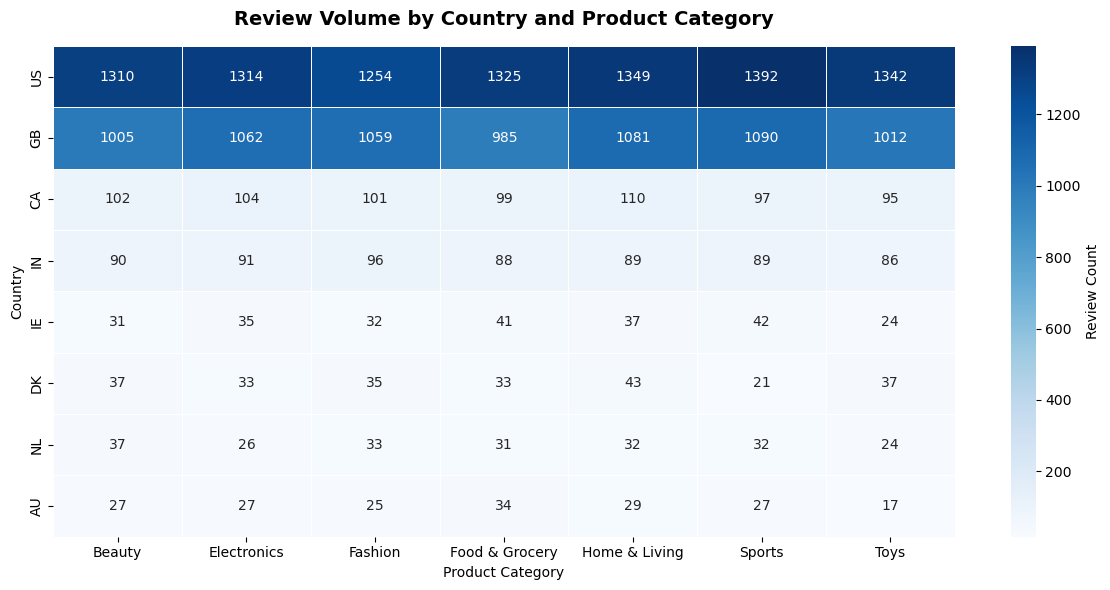

In [6]:
import seaborn as sns

top_8_countries = df['country'].value_counts().head(8).index
df_top8 = df[df['country'].isin(top_8_countries)]

pivot = df_top8.groupby(['country', 'product_category']).size().unstack(fill_value=0)
pivot = pivot.reindex(top_8_countries)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Review Count'})
ax.set_title('Review Volume by Country and Product Category', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Product Category')
ax.set_ylabel('Country')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'production_category_country_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

## Category Preference by Country Finding

Category preferences show no meaningful variation across top markets, 
within both the US and GB, review volume is evenly spread across all 
seven product categories, ranging only narrowly, 1,254 to 1,392 for 
the US and 985 to 1,090 for GB. Smaller markets follow the same flat 
pattern at proportionally lower volumes.

**Insight:** Unlike sentiment, which varies meaningfully by geography, 
product category preference appears consistent across markets, 
suggesting customers across regions purchase a similar mix of products 
from ShopEase Europe. This indicates that the sentiment differences 
identified earlier are more likely driven by service quality, delivery, 
or support factors specific to each region, rather than differences in 
what customers are buying.